# What's left for you in the semester

1. Descriptive statistics (today) - theory
2. RFM (recency, frequency, monetary) analyis - practical case study of a standard data analyst tool
3. A/B tests (3 sessions in total) - theory + interactive practice
4. Case study of real-life interview question (Send more interview questions you might have received!)
5. Project time!

# Descriptive statistics

**Descriptive statistics** are a set of tools we can use to extract the main information from a large set of data points.The most common tools


Measures of central tendency:
1. Mean
2. Median
3. Mode

Measures of dispersion:
1. Standard deviation and variance
2. Quantiles, quartiles and percentiles

Useful analytical tools for reporting:

1. Detection of outliers
2. Correlation coefficient


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
from scipy.stats import pearsonr
from scipy.stats import spearmanr
import ast

In [ ]:
orders = pd.read_csv("https://github.com/obreit/redi/raw/master/olist_dataset/orders_enriched.csv.zip")

orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders = orders.rename(columns={'avg_review_score': 'review_score'})

orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   order_status                   99441 non-null  object        
 2   number_of_items                98666 non-null  float64       
 3   categories_of_items            98666 non-null  object        
 4   order_price                    98666 non-null  float64       
 5   order_shipping_cost            98666 non-null  float64       
 6   review_score                   98673 non-null  float64       
 7   customer_city                  99441 non-null  object        
 8   customer_state                 99441 non-null  object        
 9   customer_unique_id             99441 non-null  object        
 10  order_purchase_timestamp       99441 non-null  datetime64[ns]
 11  order_delivered

In [ ]:
orders.head()

,order_id,order_status,number_of_items,categories_of_items,order_price,order_shipping_cost,review_score,customer_city,customer_state,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,1.0,['housewares'],29.99,8.72,4.0,sao paulo,SP,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-10 21:25:13
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,1.0,['perfumery'],118.70,22.76,4.0,barreiras,BA,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-08-07 15:27:45
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,1.0,['auto'],159.90,19.22,5.0,vianopolis,GO,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-17 18:06:29
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,1.0,['pet_shop'],45.00,27.20,5.0,sao goncalo do amarante,RN,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-12-02 00:28:42
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,1.0,['stationery'],19.90,8.72,5.0,santo andre,SP,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-16 18:17:02


-----
# PART 1: Measures of central tendency

The **mean/average** is with no doubt the most commom way of expressing the central tendency of the data. However, in many cases, the median or the mode are more appropriate. We must know when it is best to use each of these measures.   

The **median** is the value that divide the data points into 2 groups of same size (same number of observations/datapoints).

The **mode** is the most commom value in a set of data points.


![Mean, meadian and mode](https://images.prismic.io/sketchplanations/6ba54e4b-f936-4cf6-bc4e-a889a439c454_81825142840.jpg)

## Mean and median

`Means and medians in Python`: we can use `numpy` and `pandas`

In [ ]:
a = [5, 7, 2, 10, 13, 2000]
np.mean(a)

np.float64(339.5)

In [ ]:
b = [276, 53, 7, 13, 20]
np.sort(b)

array([  7,  13,  20,  53, 276])

In [ ]:
np.median(b)

np.float64(20.0)

In [ ]:
c = [276, 53, 7, 104, 20, 13]
np.sort(c)

array([  7,  13,  20,  53, 104, 276])

In [ ]:
(20 + 53) / 2

36.5

In [ ]:
np.median(c)

np.float64(36.5)

In [ ]:
# If there are an even number of elements, the median is the average of the
# two "middle" elements:
# median = (e1 + e2) / 2
np.median(a), np.median(b), np.median(c)

(np.float64(8.5), np.float64(20.0), np.float64(36.5))

**The median is not affected by the extreme values of a variable**.
This is the most important property of the median that you must always remember.
How can we demonstrate that in practice?

In [ ]:
np.mean([1, 4, 7, 8, 10]), np.median([1, 4, 7, 8, 10])

(np.float64(6.0), np.float64(7.0))

In [ ]:
np.mean([1, 4, 7, 8, 1000]), np.median([1, 4, 7, 8, 1000])

(np.float64(204.0), np.float64(7.0))

### Let's compare the mean and median order prices from the *olist* dataset

In [ ]:
orders['order_price'].mean(), orders['order_price'].median()

(np.float64(137.75407637889447), 86.9)

If both the mean and median are describing the central tendency of the same data, why are they so different?

Use a **histogram** in the data to try to find the answer:  

*Also check [this blog post](https://chartio.com/learn/charts/histogram-complete-guide/) for a very good tutorial on histograms*

In [ ]:
orders.value_counts('order_price')

,count
order_price,
59.90,1723
69.90,1605
49.90,1420
89.90,1248
99.90,1191
...,...
3899.00,1
3700.00,1
3699.99,1


In [ ]:
orders.value_counts('order_price').sort_index()

,count
order_price,
0.85,2
2.20,1
2.29,1
2.90,1
2.99,1
...,...
6499.00,1
6729.00,1
6735.00,1


<Axes: xlabel='order_price', ylabel='Count'>

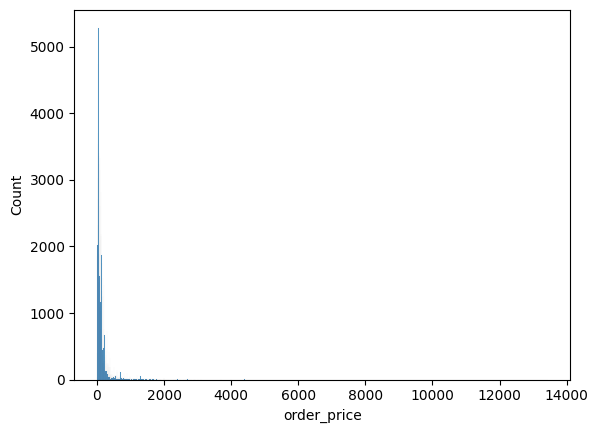

In [ ]:
sns.histplot(orders['order_price'], bin=10)

<Axes: xlabel='order_price', ylabel='Count'>

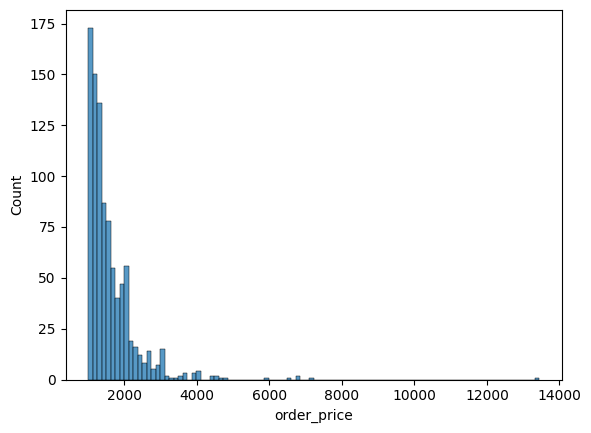

In [17]:
sns.histplot(orders[orders['order_price'] >= 1000]['order_price'])

<Axes: xlabel='order_price', ylabel='Count'>

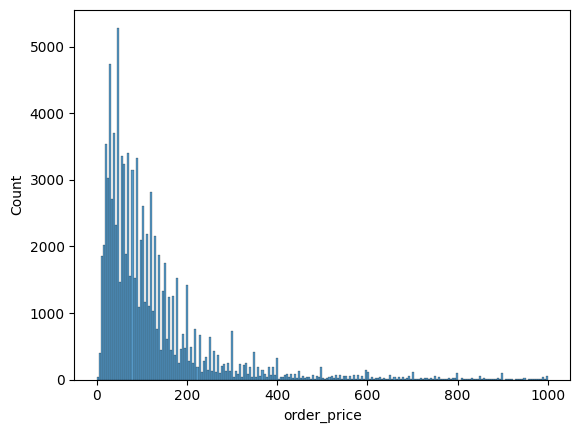

In [18]:
sns.histplot(orders[orders['order_price'] < 1000]['order_price'])

In [19]:
orders[orders['order_price'] < 200].sample(10)

,order_id,order_status,number_of_items,categories_of_items,order_price,order_shipping_cost,review_score,customer_city,customer_state,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date
56371,2321c02e9006c158014df8d2e9b00225,delivered,1.0,['watches_gifts'],134.90,26.22,5.0,fortaleza,CE,9fb1d9a8bc1e3c025d1761dbfe63da36,2017-09-24 12:37:01,2017-10-11 21:22:54
89373,ea0640a9f021b9f129b25d54e4c649f2,delivered,1.0,['watches_gifts'],55.00,17.10,1.0,salvador,BA,3d86b969fd5c7e342968ee81b92b6b06,2018-06-06 21:40:31,2018-08-01 20:48:33
82029,cad74364289ac320e036ecf2a457c562,delivered,1.0,['watches_gifts'],59.00,14.16,3.0,rio de janeiro,RJ,1c7654b568e0413ca7b8f7a891d7b26b,2017-11-07 21:57:26,2017-11-13 22:13:01
26134,f7411b386b99ab297f888848be4198a6,delivered,1.0,['bed_bath_table'],39.00,18.23,3.0,santa luzia,MG,a386f0811120348f75f03b133eb083ec,2018-05-15 12:23:49,2018-06-01 20:08:24
93385,07664da4fa93862f7f2f3fd353b99e73,delivered,1.0,['stationery'],129.00,20.14,5.0,mata de sao joao,BA,781d55b671e8b6020c3e791c514c2519,2018-01-09 08:45:00,2018-02-06 18:59:06
13953,4bd68cb4a5f7a692f05af3eb298c4039,delivered,1.0,['sports_leisure'],25.90,7.78,3.0,americana,SP,6b1549c509ef8c31aa1eaa92f318e5b8,2017-07-31 16:33:37,2017-08-14 11:54:03
3597,373050e6af734517549f69f888763324,delivered,1.0,['housewares'],72.00,17.41,5.0,vargem grande do sul,SP,2e2184d1356da6b014de1af7efb0f093,2018-05-10 22:39:19,2018-05-18 14:51:44
86467,f8033eab5248939afe7fa7feb4ac4866,delivered,1.0,['toys'],99.90,18.00,5.0,aparecida de goiania,GO,8f57542916bc546e32ae566f90301036,2017-10-27 23:54:00,2017-11-07 20:36:29
9663,2cb13a60aa8162ece6fbc46f608f56b5,delivered,1.0,['electronics'],14.90,12.48,2.0,carlopolis,PR,3e71a942be00f8d0d0cc4b01880f7a17,2017-08-23 07:04:54,2017-09-05 22:13:56
10795,53fa1584e9fc3d9b50f19da601874fd5,delivered,1.0,['toys'],99.99,8.11,4.0,mesquita,RJ,47d247db5e582120cf919464317250ce,2017-09-13 08:03:54,2017-09-16 13:57:36


In [20]:
orders[orders['order_price'] >= 1000].sample(10)

,order_id,order_status,number_of_items,categories_of_items,order_price,order_shipping_cost,review_score,customer_city,customer_state,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date
77109,1b0bc119ea5ac37e73e2275afc7904ee,delivered,3.0,"['furniture_decor', 'furniture_decor', 'comput...",1467.80,75.45,1.0,sao paulo,SP,34cd0f2f38a66796cfbc8a33ece7448c,2018-08-14 14:19:51,2018-08-23 03:24:50
3061,ea110ced6459b4dc6c73e0b2367077e9,delivered,1.0,['construction_tools_construction'],1890.00,25.53,5.0,sao paulo,SP,95376669d92be6a7dcf0494e0b1d9917,2018-06-17 20:32:45,2018-06-19 21:33:32
57046,6a4bb813a7219502638206778564481d,delivered,1.0,['baby'],1849.00,42.07,5.0,ferraz de vasconcelos,SP,7b0eaf68a16e4808e5388c67345033c9,2018-05-19 11:16:55,2018-05-28 15:46:43
60372,bc488184689ceaa10ede9045693eb6bc,delivered,1.0,['garden_tools'],1670.00,59.98,1.0,aracaju,SE,2f0ce2fb407114dbfa866f22c7cf9e9d,2018-04-03 11:35:18,2018-05-11 19:36:55
39539,059fd94aa8716f14743caff2f433be05,delivered,1.0,['consoles_games'],1314.99,53.88,5.0,aracaju,SE,8be5c6cc1011c8a882d3bac857955b3d,2018-02-24 14:59:06,2018-03-12 14:27:35
45520,fc0b3be9d66d6db8d306c15407ece0d7,delivered,1.0,['health_beauty'],1299.65,59.82,5.0,natal,RN,1159db37e256a4e27f777ebd08b4da05,2018-06-16 20:45:44,2018-06-28 21:12:50
50677,0eeae75286b79b40f203057933fbb70b,delivered,2.0,"['stationery', 'stationery']",1727.00,57.20,1.0,natal,RN,c11f76d3806da64a4c64ea47627444e2,2018-05-05 14:42:25,2018-05-24 15:23:49
54423,d1ea13fc1406243e6f6134582bf1bbc5,delivered,1.0,['small_appliances'],1399.00,33.92,5.0,rio de janeiro,RJ,6899ba25b05f771af3ede719ef5c861f,2018-05-19 18:18:10,2018-06-06 16:49:57
75627,543191db0a8f28cd664d601260fb1dee,delivered,1.0,['sports_leisure'],1599.00,115.21,2.0,parnamirim,PE,55b2d632bc5b7859767c1efd222c1659,2018-01-14 12:57:25,2018-02-27 16:21:48
66599,736e1922ae60d0d6a89247b851902527,delivered,4.0,"['fixed_telephony', 'fixed_telephony', 'fixed_...",7160.00,114.88,1.0,vila velha,ES,763c8b1c9c68a0229c42c9fc6f662b93,2018-07-15 14:49:44,2018-07-26 22:03:06


In [21]:
orders[orders['order_price'] == 13440]

,order_id,order_status,number_of_items,categories_of_items,order_price,order_shipping_cost,review_score,customer_city,customer_state,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date
13390,03caa2c082116e1d31e67e9ae3700499,delivered,8.0,"['fixed_telephony', 'fixed_telephony', 'fixed_...",13440.0,224.08,1.0,rio de janeiro,RJ,0a0a92112bd4c708ca5fde585afaa872,2017-09-29 15:24:52,2017-10-17 18:22:29


The histogram of the *order_price* shows an example of a variable with **skewed distribution**. It means that there are more datapoints on the left side of the mean than on the right side. In these cases, the median is lower than the mean. Since the median is not affected by the extreme values of a variable, it is more appropriate to use it when the distribution is skewed.

<img src="https://cdn.analyticsvidhya.com/wp-content/uploads/2020/06/sk1.png" width="600">


-----
## Mode

This is the most apropriate measure for discrete data, or categorical data (where we make counts of categories)
Samples can have one (unimodal), two (bimodal), or many (multimodal) modes

<img src="https://miro.medium.com/max/810/1*-jZA9f5l1RaEKvPoFMz5BQ.png" alt="Drawing" width="300"/>

**Example:**
In the *orders* dataset, from which state are most orders placed?

In other words, what is the **mode** of the variable `customer_state`?

<Axes: xlabel='customer_state', ylabel='Count'>

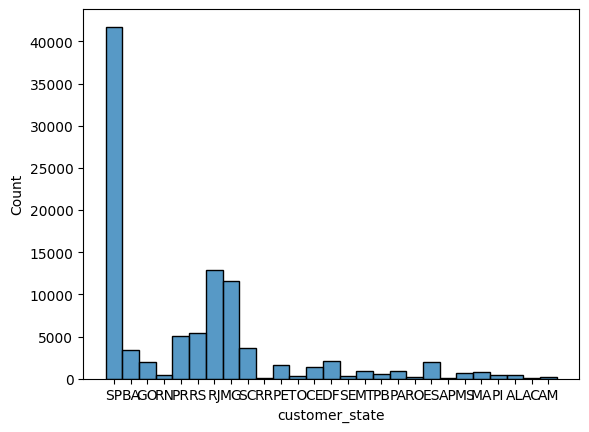

In [22]:
sns.histplot(orders['customer_state'])

<Axes: xlabel='customer_state'>

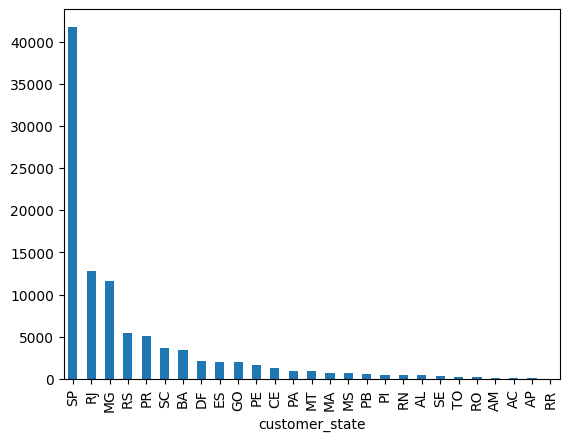

In [23]:
# displaying the results sorted by frequency
orders.value_counts('customer_state').sort_values(ascending=False).plot.bar()

<Axes: xlabel='customer_state'>

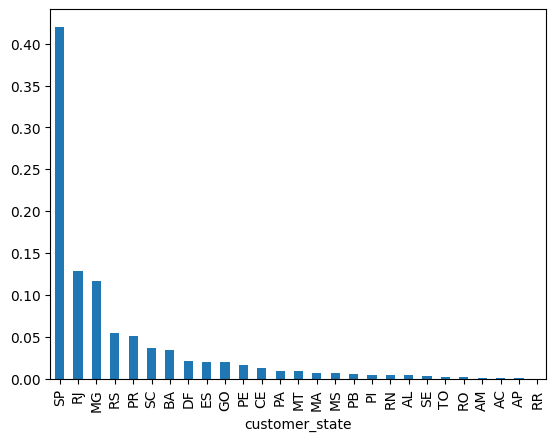

In [24]:
orders['customer_state'].value_counts(normalize=True).plot.bar()

<Axes: xlabel='review_score', ylabel='Count'>

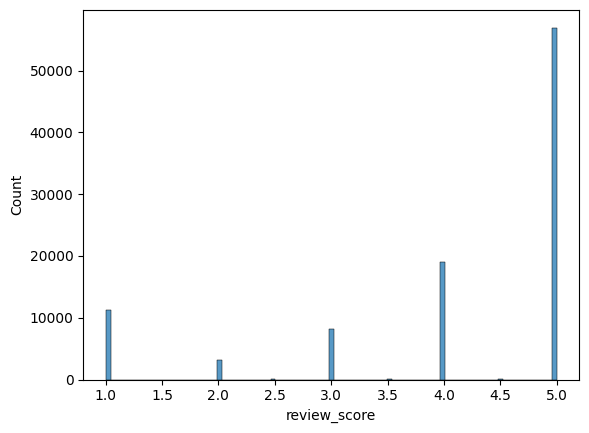

In [25]:
sns.histplot(orders['review_score']) # 1 - 5

<Axes: xlabel='review_score'>

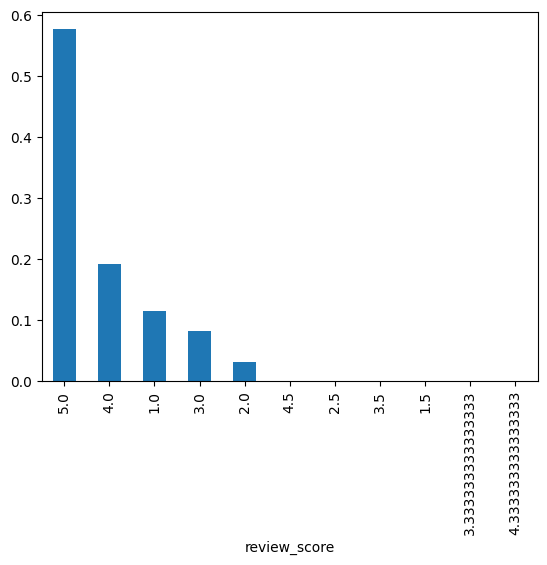

In [26]:
# displaying the results sorted by frequency
orders['review_score'].value_counts(normalize=True).sort_values(ascending=False).plot.bar()

In [27]:
# mean doesn't make much sense - or rather, is not that useful - for the review score
orders['review_score'].mean(), orders['review_score'].median()

(np.float64(4.0867934152875325), 5.0)

In [28]:
orders['review_score'].mode()

,review_score
0,5.0


Is the distribution of `review_score` unimodal, bimodal, or multimodal?

Instead of saying that the average review score is ~4, it's more useful to say that
* almost 60% of the reviews are 5.0
* almost 20% of the reviews are 4.0
* around 12% of the reviews are 1.0

**Bimodal distribution**

The plot shows the number of customers that visit a restaurant and the hour that they visit. We can see the 2 modes (2 peaks), representing the lunch peak (12PM) and the dinner peak (7PM). It would be very misleading to use the mean to summarize the time when customers come to the restaurant, because it would be somewhere before 4PM, which is in fact, the time when the restaurant is the least busy

<img src="https://www.statology.org/wp-content/uploads/2020/06/bimodal3.png" alt="Drawing" width="500"/>

### Delivery Delay case study

Let's describe how long it takes for an order to be delivered

1. Use the *order_purchase_timestamp* (when the order was placed) and *order_delivered_customer_date* (when the order arrived) columns
2. Compute the difference of these two timestamps (in pandas this can be achieved with a simple minus (-) operation)
3. Extract the number of days from this time difference (see https://pandas.pydata.org/docs/reference/series.html#datetime-properties for help)
4. Store the result in a variable *delivery_delay_in_days*

5. Summarize the variable in different ways (mean, median, mode, histogram). Which summary is the most appropriate for this variable?

In [29]:
# 1. difference between order delivery and the order purchase
orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']

,0
0,8 days 10:28:40
1,13 days 18:46:08
2,9 days 09:27:40
3,13 days 05:00:36
4,2 days 20:58:23
...,...
99436,8 days 05:13:56
99437,22 days 04:38:58
99438,24 days 20:37:34
99439,17 days 02:04:27


In [30]:
delivery_delays_in_days = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days

delivery_delays_in_days

,0
0,8.0
1,13.0
2,9.0
3,13.0
4,2.0
...,...
99436,8.0
99437,22.0
99438,24.0
99439,17.0


In [31]:
# average delivery time. it takes ~2 weeks for an order to be delivered
np.mean(delivery_delays_in_days)

np.float64(12.094085575687217)

In [32]:
#np.median(delivery_delays_in_days)

np.nanmedian(delivery_delays_in_days)

# np.nanmedian() == delivery_delays_in_days.median()
#delivery_delays_in_days.median()

np.float64(10.0)

In [33]:
delivery_delays_in_days.mode()

,0
0,7.0


<Axes: ylabel='Count'>

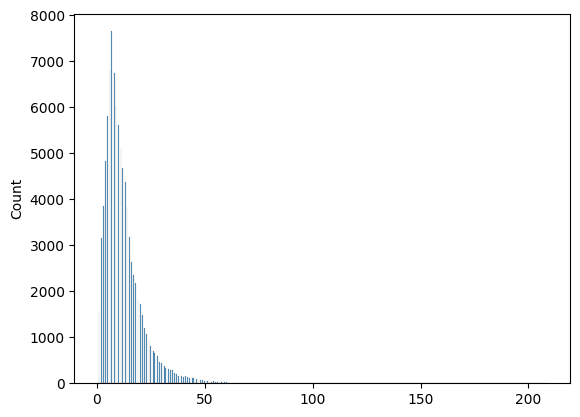

In [34]:
sns.histplot(delivery_delays_in_days)

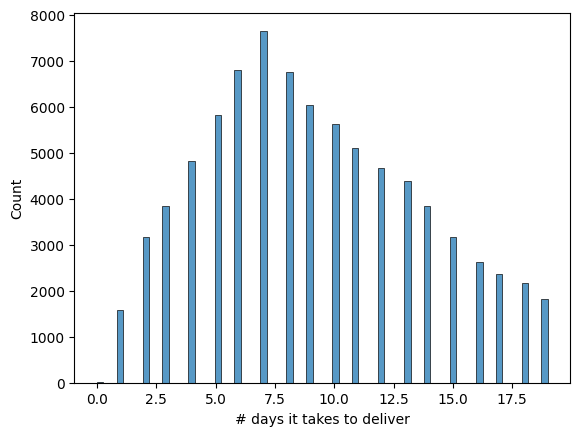

In [35]:
ax = sns.histplot(delivery_delays_in_days[delivery_delays_in_days < 20])
_ = ax.set(xlabel='# days it takes to deliver')

----
# PART 2: Measures of dispersion

Everytime we use some measure of central tendency (mean, median) it is **best practice** to show some measure of dispersion. They help us understand how well the mean/median is representing the data.

Commom measures of dispersion:
* standard deviation
* quartiles or interquartile range (IQR)
* 95% confidence intervals



## Standard deviation


* The most common dispersion metric is the **standard deviation**,
* the best tool to help us understand the dispersion in our data is the **histogram**.

To calculate the **standard deviation**:


1.   Calculate the mean
2.   Calculate the distance of each datapoint to the mean and square it
3.   Sum the squared values
4. Divide the sum by the number of samples (at this point we have calculated the **variance**)
5.   Take the squared root of the final value

https://en.wikipedia.org/wiki/Standard_deviation



In [36]:
# Why we square the distances in step 2?
# Because of an important property of the mean. If you subtract the mean from each value
# and sum everything up, you end up with 0.
# 'values - mean' are the 'residuals'. The sum of the residuals is always 0!

values = [2, 3, 40, 56, 900]

mean = np.mean(values)

np.sum(values - mean)

np.float64(0.0)

In [37]:
residuals = values - mean
residuals_squared = residuals ** 2
np.sum(residuals_squared)

np.float64(614348.7999999999)

Calculating the **standard deviation** of a sample:

In [38]:
# What is the mean height of a sample of people (in cm)?
values = [160, 169, 165, 168, 168, 168, 173, 180, 139]

mean = np.mean(values)

variance = np.sum(((values-mean)**2)) / len(values)

sd = np.sqrt(variance)

In [39]:
sd

np.float64(10.699024993076197)

In [40]:
assert np.std(values) == sd

### Interpretation of standard deviation:  

when the standard deviation is high (relative to the mean), it means a lot of variability in the data.   
It makes it way more difficult to make clear conclusions from data that is highly variable.

Histograms can help a lot to understand the distribution of our values:

<img src="https://d20khd7ddkh5ls.cloudfront.net/high_low_standard_deviation.png" width="300" />


In [41]:
# semantics of explode
pd.Series([[1,2], [1,2,3]])

,0
0,"[1, 2]"
1,"[1, 2, 3]"


In [42]:
pd.Series([[1,2], [1,2,3]]).explode()

,0
0,1
0,2
1,1
1,2
1,3


In [43]:
# create 1 row for each item category in an order.
# For example, if an order has categories_of_items: [a,b,c] we get 3 output rows

def try_parse(s):
  try:
    return ast.literal_eval(s)
  except:
    return None

orders['item_category'] = orders['categories_of_items'].apply(try_parse)

orders_exploded = orders.explode('item_category').reset_index(drop=True)

In [44]:
orders_exploded

,order_id,order_status,number_of_items,categories_of_items,order_price,order_shipping_cost,review_score,customer_city,customer_state,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,item_category
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,1.0,['housewares'],29.99,8.72,4.0,sao paulo,SP,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-10 21:25:13,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,1.0,['perfumery'],118.70,22.76,4.0,barreiras,BA,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-08-07 15:27:45,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,1.0,['auto'],159.90,19.22,5.0,vianopolis,GO,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-17 18:06:29,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,1.0,['pet_shop'],45.00,27.20,5.0,sao goncalo do amarante,RN,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-12-02 00:28:42,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,1.0,['stationery'],19.90,8.72,5.0,santo andre,SP,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-16 18:17:02,stationery
...,...,...,...,...,...,...,...,...,...,...,...,...,...
113179,63943bddc261676b46f01ca7ac2f7bd8,delivered,1.0,['baby'],174.90,20.10,4.0,praia grande,SP,da62f9e57a76d978d02ab5362c509660,2018-02-06 12:58:58,2018-02-28 17:37:56,baby
113180,83c1379a015df1e13d02aae0204711ab,delivered,1.0,['home_appliances_2'],205.99,65.02,5.0,nova vicosa,BA,737520a9aad80b3fbbdad19b66b37b30,2017-08-27 14:46:43,2017-09-21 11:24:17,home_appliances_2
113181,11c177c8e97725db2631073c19f07b62,delivered,2.0,"['computers_accessories', 'computers_accessori...",359.98,81.18,2.0,japuiba,RJ,5097a5312c8b157bb7be58ae360ef43c,2018-01-08 21:28:27,2018-01-25 23:32:54,computers_accessories
113182,11c177c8e97725db2631073c19f07b62,delivered,2.0,"['computers_accessories', 'computers_accessori...",359.98,81.18,2.0,japuiba,RJ,5097a5312c8b157bb7be58ae360ef43c,2018-01-08 21:28:27,2018-01-25 23:32:54,computers_accessories


In [45]:
item_category_mean_std = orders_exploded.groupby('item_category').agg({'order_price': [np.mean, np.std]}).reset_index()

<ipython-input-45-5f615c2cdee7>:1: FutureWarning: The provided callable <function mean at 0x7e50d6302020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  item_category_mean_std = orders_exploded.groupby('item_category').agg({'order_price': [np.mean, np.std]}).reset_index()
<ipython-input-45-5f615c2cdee7>:1: FutureWarning: The provided callable <function std at 0x7e50d6302160> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  item_category_mean_std = orders_exploded.groupby('item_category').agg({'order_price': [np.mean, np.std]}).reset_index()


In [46]:
item_category_mean_std

item_category order_price             
                                      mean          std
0   agro_industry_and_commerce  520.438915  1015.058055
1             air_conditioning  271.833704   323.452337
2                          art  124.567847   446.044647
3        arts_and_craftmanship   79.403333    71.750248
4                        audio  148.572033   173.835448
..                         ...         ...          ...
66                  stationery  103.895016    95.750402
67      tablets_printing_image  104.106145   102.302849
68                   telephony   87.622849   163.666053
69                        toys  128.920982   141.809398
70               watches_gifts  218.779960   274.485216

[71 rows x 3 columns]

<ipython-input-47-1800969df839>:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


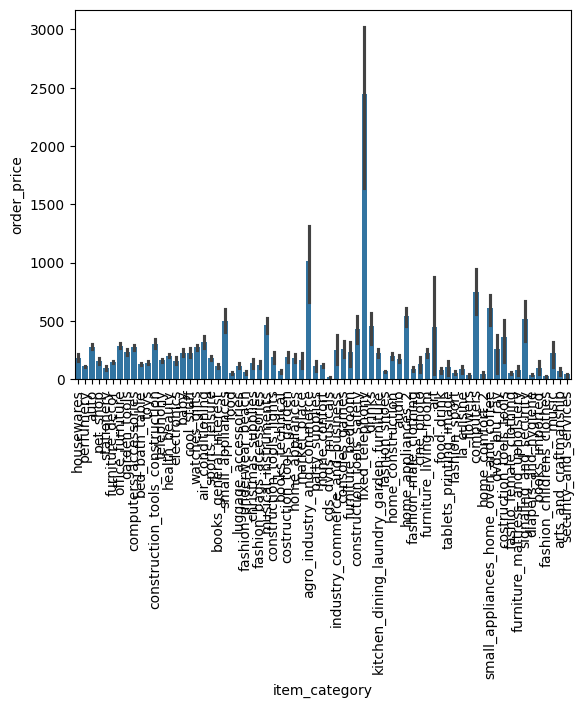

In [47]:
# plot the mean and standard deviation for each item category
ax = sns.barplot(data=orders_exploded, x='item_category', y='order_price', estimator=np.std)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

In [48]:
# for a bit more clarity, only use a subset of the items
def filter_orders_by_items(orders_df, items_mean_std_df, filter_function):
  items_filter = items_mean_std_df[filter_function]['item_category']

  return orders_df[orders_df['item_category'].isin(items_filter)]

<ipython-input-49-d8fedfa55c4b>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


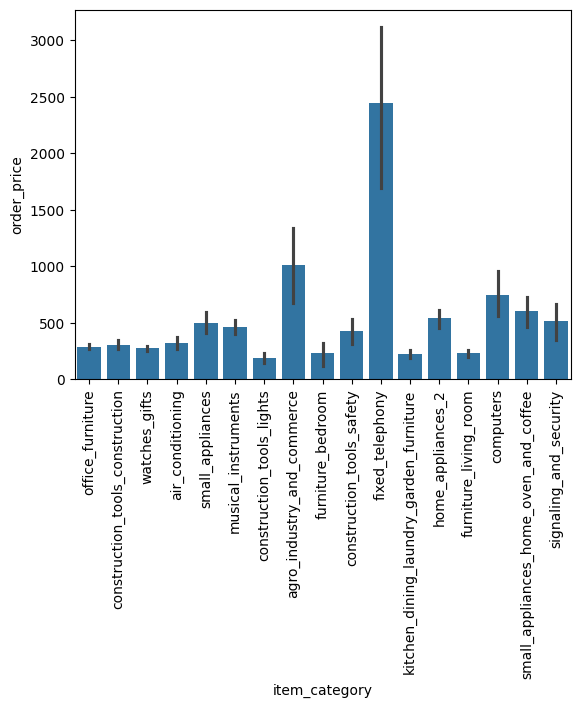

In [49]:
expensive_items = filter_orders_by_items(orders_exploded, item_category_mean_std, lambda icat: icat['order_price']['mean'] > 200)

ax = sns.barplot(data=expensive_items, x='item_category', y='order_price', estimator=np.std)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

<ipython-input-50-f3498fd57620>:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


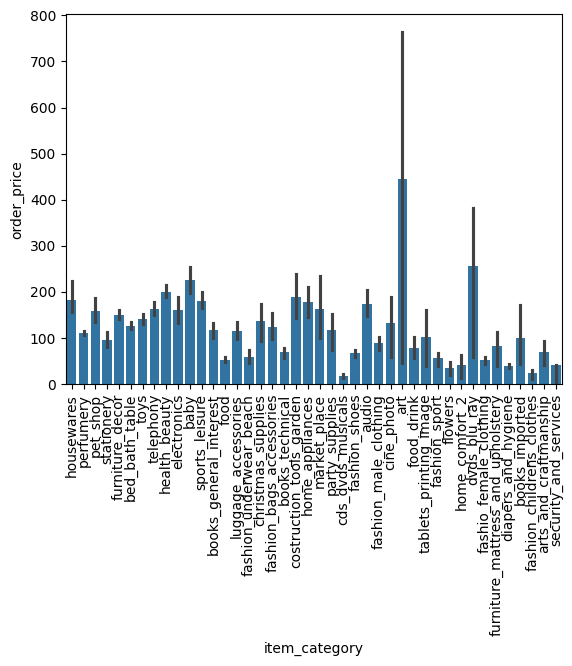

In [50]:
cheap_items = filter_orders_by_items(orders_exploded, item_category_mean_std, lambda icat: icat['order_price']['mean'] < 150)

ax = sns.barplot(data=cheap_items, x='item_category', y='order_price', estimator=np.std)

_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

## Quartiles and percentiles

They tell us how many samples (datapoints) we can expect in a specific range. There's a nice blog post about it [here](https://medium.com/@vinitasilaparasetty/quartiles-for-beginners-in-data-science-cad074cf5d65)  

**Quartiles** are 3 values that divide the datapoints into 4 portions (the 25%, 50%, 75%, 100%)


Imagine we have a class with 11 students and they take a test. The image below shows the scores of each student in a test, sorted in ascending order (2 students had 2 points, one student had 4 points and so on). Interpretation:  

* The **first quartile** is 4, which means that 25% of the students had a score of up to 4 points.  
* The **second quartile** is 5, which means that 50% of the students had a score of up to 5 points.  
* The **third quartile** is 9, which means that 75% of the students had a score of up to 9 points.   

<img src="https://cdn.scribbr.com/wp-content/uploads/2022/05/Quartile-example.webp" width="500" />

**Percentiles** are any fraction of the data we might be interested (from 0 to 1)

In [51]:
# 25% of the orders were less than ? money
orders['order_price'].quantile(0.25)

np.float64(45.9)

In [52]:
# 75% of the orders were less than ? money
orders['order_price'].quantile(0.75)

np.float64(149.9)

In [53]:
# 0.5 quantile is the median!
orders['order_price'].quantile(0.5), orders['order_price'].median()

(np.float64(86.9), 86.9)

In [54]:
# 90% of the orders were less than ? money
orders['order_price'].quantile(0.9)

np.float64(269.9)

In [55]:
# 0% of the orders were less than ? money == min
orders['order_price'].quantile(0), orders['order_price'].min()

(np.float64(0.85), 0.85)

In [56]:
# 100% of the orders were less than ? money == max
orders['order_price'].quantile(1), orders['order_price'].max()

(np.float64(13440.0), 13440.0)

### Interquartile range

IQR is also a measure of dispersion, and is the range between the first and the third quartiles namely Q1 and Q3:  

**IQR = Q3 – Q1**

We know that 50% of all datapoints fall within the range between Q1 and Q3

In [57]:
# What is the IQR of delay in deliveries?
iqr_delays = delivery_delays_in_days.quantile(0.75) - delivery_delays_in_days.quantile(0.25)

iqr_delays

np.float64(9.0)

## Confidence intervals

Confidence intervals are a tool to help **generalize** our findings to a bigger sample, which we did not/ cannot measure ourselves.

*Example*: we can measure the height of all students in this class, but we cannot obtain the heights of all human beings alive. But after having a sample of some individuals, we might want to generalize the findings to the entire country population.

In [58]:
heights_in_cm = [160, 160, 166, 173, 155, 176, 156]

# Create 95% confidence interval for the sample above
stats.t.interval(confidence=0.95, df=len(heights_in_cm)-1, loc=np.mean(heights_in_cm), scale=np.std(heights_in_cm))

(np.float64(145.0922789560732), np.float64(182.33629247249826))

In [59]:
np.mean(heights_in_cm)

np.float64(163.71428571428572)

Confidence interval for different groups

In [60]:
def compute_confidence_interval(group):
  return stats.t.interval(confidence=0.95, df=len(group)-1, loc=np.mean(group), scale=stats.sem(group))

items_cis = orders_exploded.groupby('item_category')['order_price'].agg([np.mean, np.std, stats.sem, compute_confidence_interval]).reset_index()

items_cis[items_cis['mean'] > 500]

<ipython-input-60-c8a1a0c7fb09>:4: FutureWarning: The provided callable <function mean at 0x7e50d6302020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  items_cis = orders_exploded.groupby('item_category')['order_price'].agg([np.mean, np.std, stats.sem, compute_confidence_interval]).reset_index()
<ipython-input-60-c8a1a0c7fb09>:4: FutureWarning: The provided callable <function std at 0x7e50d6302160> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  items_cis = orders_exploded.groupby('item_category')['order_price'].agg([np.mean, np.std, stats.sem, compute_confidence_interval]).reset_index()


,item_category,mean,std,sem,compute_confidence_interval
0,agro_industry_and_commerce,520.438915,1015.058055,69.714473,"(383.01281995984755, 657.8650102288318)"
14,computers,1313.865961,748.082022,52.505065,"(1210.3376612722411, 1417.3942599100249)"
34,fixed_telephony,750.538106,2449.228759,150.739610,"(453.72804972608003, 1047.348162395132)"
64,small_appliances_home_oven_and_coffee,636.838289,611.314172,70.122545,"(497.1470171456101, 776.5295618017583)"


In [61]:
orders.groupby('customer_state')['order_price'].agg([np.mean, np.std, stats.sem, compute_confidence_interval]).reset_index().sort_values(by='mean', ascending=False)

<ipython-input-61-fbc7d354842f>:1: FutureWarning: The provided callable <function mean at 0x7e50d6302020> is currently using SeriesGroupBy.mean. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "mean" instead.
  orders.groupby('customer_state')['order_price'].agg([np.mean, np.std, stats.sem, compute_confidence_interval]).reset_index().sort_values(by='mean', ascending=False)
<ipython-input-61-fbc7d354842f>:1: FutureWarning: The provided callable <function std at 0x7e50d6302160> is currently using SeriesGroupBy.std. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "std" instead.
  orders.groupby('customer_state')['order_price'].agg([np.mean, np.std, stats.sem, compute_confidence_interval]).reset_index().sort_values(by='mean', ascending=False)


,customer_state,mean,std,sem,compute_confidence_interval
14,PB,216.669323,366.283428,NaN,"(nan, nan)"
3,AP,198.151471,265.285252,32.170562,"(133.93875975403802, 262.3641814224325)"
0,AC,197.320370,222.003790,24.667088,"(148.23130130519752, 246.40943943554322)"
1,AL,195.413163,266.406756,NaN,"(nan, nan)"
20,RO,186.804211,287.491034,NaN,"(nan, nan)"
13,PA,184.482278,269.401401,NaN,"(nan, nan)"
26,TO,177.855699,266.800438,NaN,"(nan, nan)"
16,PI,176.296308,228.771880,NaN,"(nan, nan)"
12,MT,173.259723,255.961548,NaN,"(nan, nan)"
19,RN,172.271743,231.946182,NaN,"(nan, nan)"


# Summarizing with tables and plots

`Pandas describe()`

Pandas offers a very useful tool to describe all your dataset at once:

In [62]:
orders.describe().transpose()

,count,mean,min,25%,50%,75%,max,std
number_of_items,98666.0,1.141731,1.0,1.0,1.0,1.0,21.0,0.538452
order_price,98666.0,137.754076,0.85,45.9,86.9,149.9,13440.0,210.645145
order_shipping_cost,98666.0,22.823562,0.0,13.85,17.17,24.04,1794.96,21.650909
review_score,98673.0,4.086793,1.0,4.0,5.0,5.0,5.0,1.346274
order_purchase_timestamp,99441,2017-12-31 08:43:12.776581120,2016-09-04 21:15:19,2017-09-12 14:46:19,2018-01-18 23:04:36,2018-05-04 15:42:16,2018-10-17 17:30:18,NaN
order_delivered_customer_date,96476,2018-01-14 12:09:19.035542272,2016-10-11 13:46:32,2017-09-25 22:07:22.249999872,2018-02-02 19:28:10.500000,2018-05-15 22:48:52.249999872,2018-10-17 13:22:46,NaN


### Boxplots

Boxplots offer a visual summary of the data

<img src="https://www.wellbeingatschool.org.nz/sites/default/files/W@S_boxplot-labels.png" width="400" />

<ipython-input-63-6917898adadc>:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


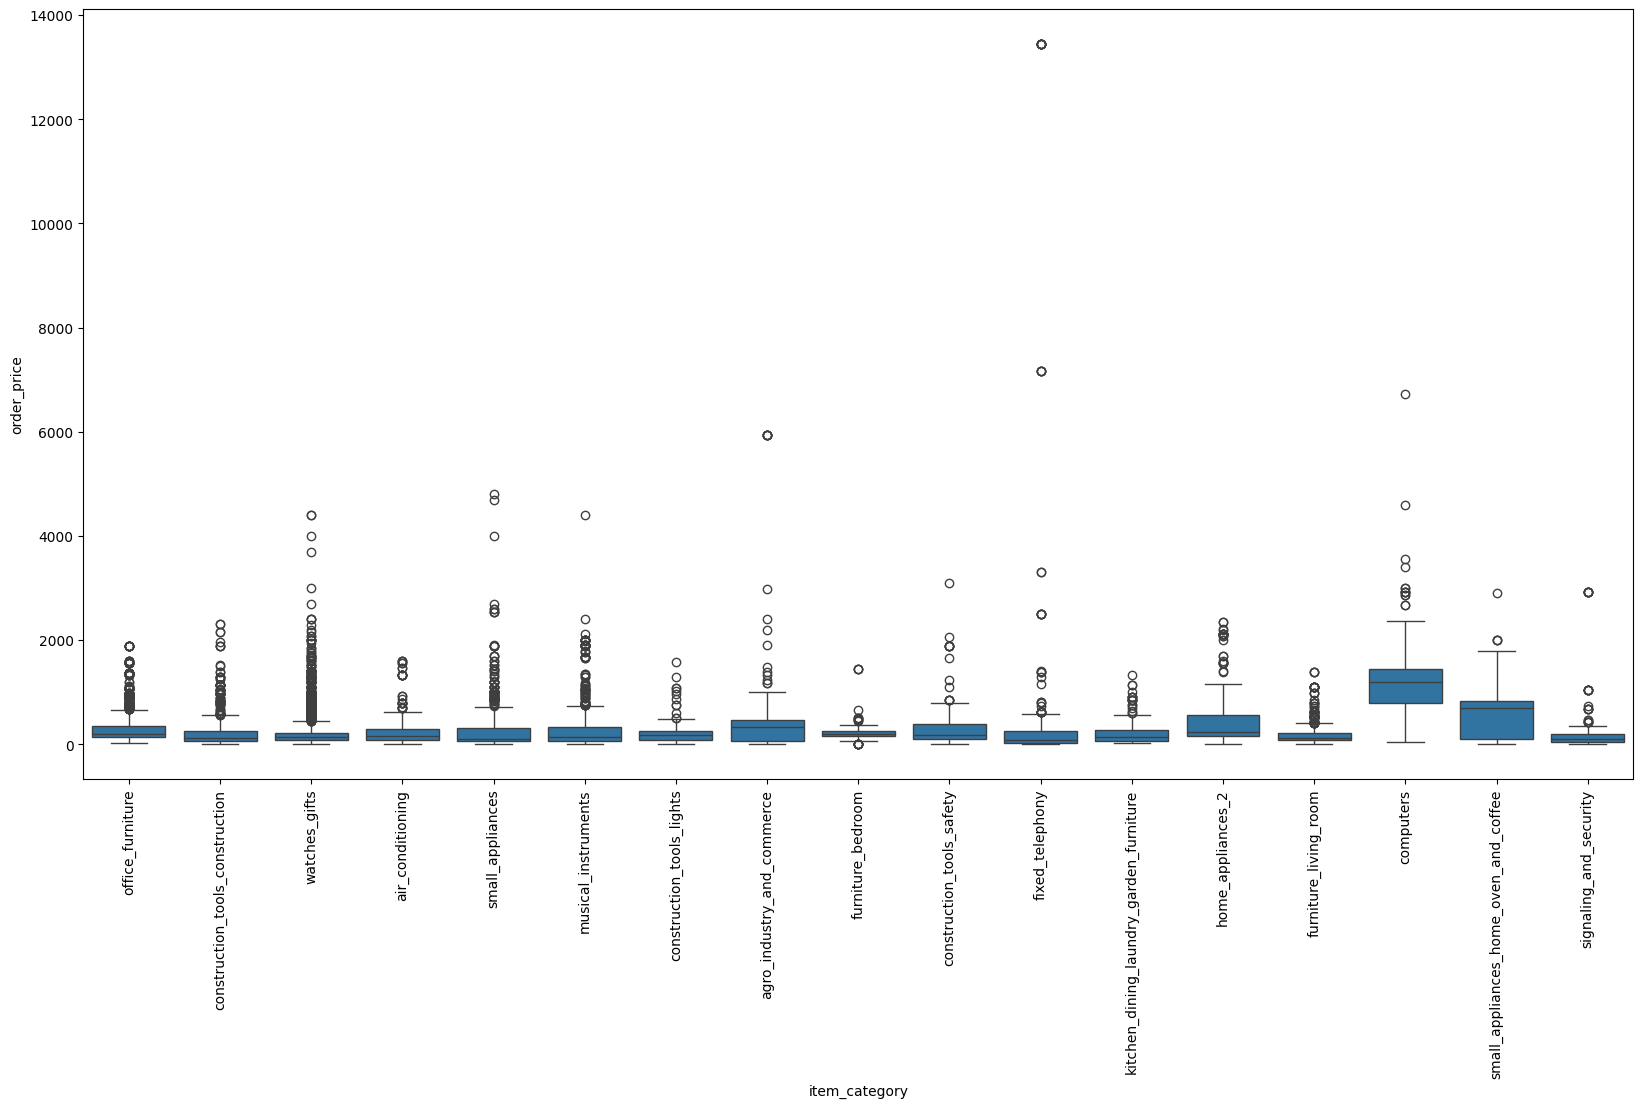

In [63]:
filtered_orders = filter_orders_by_items(orders_exploded, item_category_mean_std, lambda ic: ic['order_price']['mean'] > 200)

ax = sns.boxplot(data=filtered_orders, x='item_category', y='order_price')

fig = ax.get_figure()
fig.set_size_inches(20, 10)
_ = ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

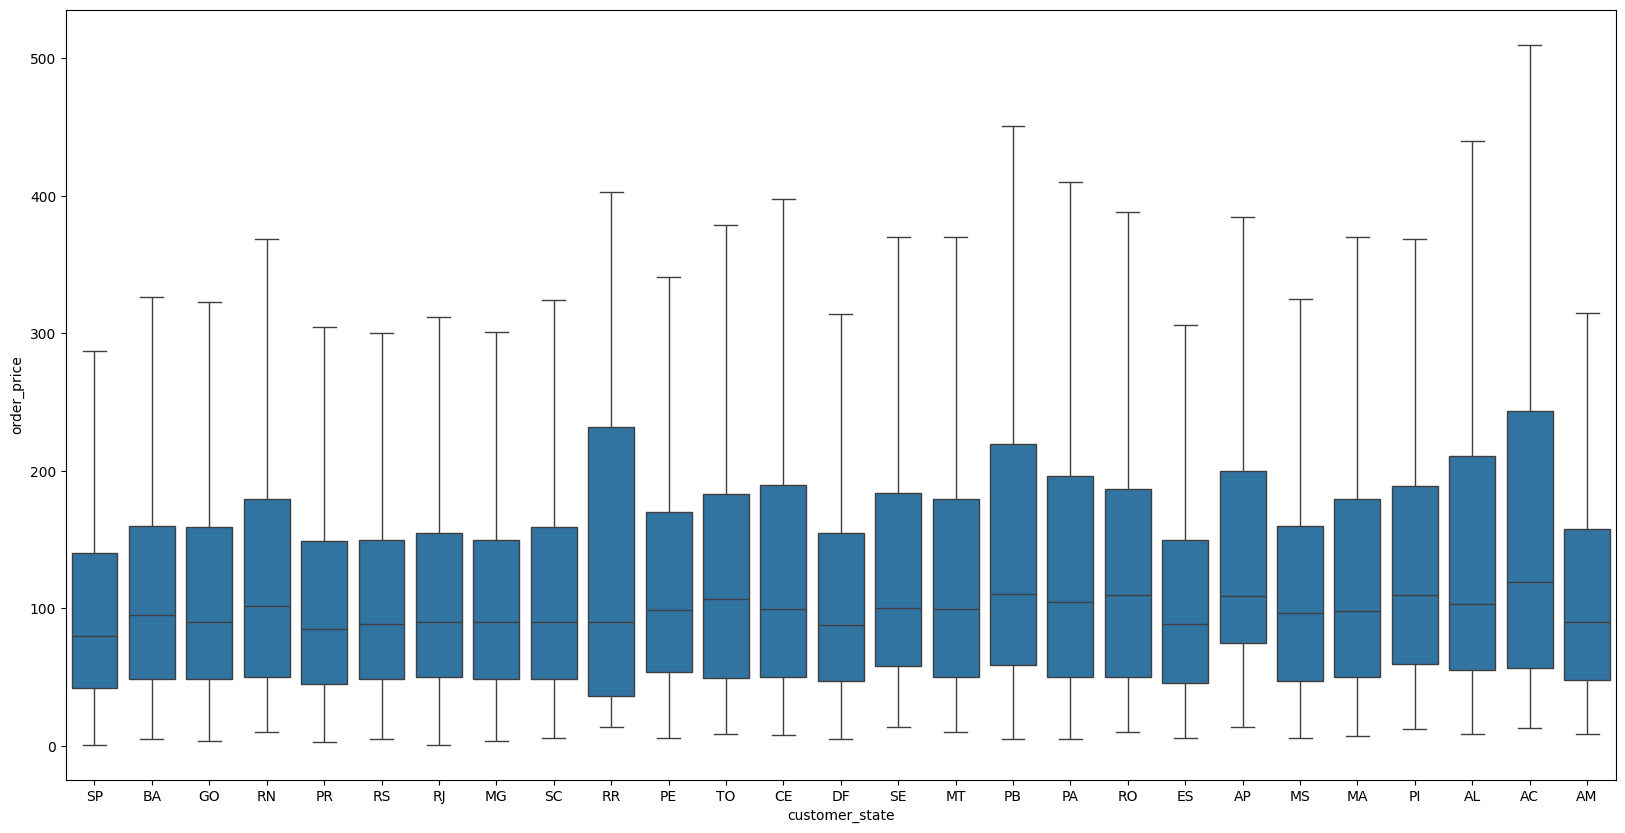

In [64]:
ax = sns.boxplot(data=orders, x='customer_state', y='order_price', showfliers=False)

fig = ax.get_figure()
fig.set_size_inches(20, 10)

# SUMMARY - Parts 1 and 2
## Best practices for reporting



*   Always start with histograms to check if the distribution is symmetrical or asymmetrical, unimodal, bimodal, or multimodal
*   Based on the shape of the distribution, choose to use either the mean or median
* Use standard deviation with the mean, or IQR with the median
* If the data is discrete or categorical, don't use means or medians. Instead, show the frequency (%) of most relevant categories (the mode/modes)

---


# PART 3

## Outlier detection

Outliers are observations that have a very low probability of occurring, if we can trust that we obtained a representative sample of the variable that we are analysing.

Reasons for the presence outliers:


1.   Human mistakes like typos, data conversion
2. Technical mistakes (equipment malfunctioning)
3.   Biased sampling
4. Presence of rare underlying factors that we know already, or not

What can we do with them?


*   If we know that they were mistakes in data collection or data preparation, we can fix them or remove them
*   Improve the sampling strategy and increase sample size


This [blog post](https://towardsdatascience.com/5-outlier-detection-methods-that-every-data-enthusiast-must-know-f917bf439210) has a very good explanation of other methods for outlier detection

**Simplest method:**
* Calculate the Q1 and Q3 of the variable
* Calculate the IQR
* The lowest threshold becomes: `Q1 – 1.5 * IQR`
* The highest threshold becomes: `Q3 + 1.5 * IQR`
* Delete the datapoints that are below the lowest threshold and above the highest threshold






In [65]:
q1 = orders['order_price'].quantile(0.25)
q3 = orders['order_price'].quantile(0.75)

IQR = q3 - q1
LThres = q1 - 1.5 * IQR
HThres = q3 + 1.5 * IQR

IQR, LThres, HThres

(np.float64(104.0), np.float64(-110.1), np.float64(305.9))

In [66]:
orders['order_price'].describe()

,order_price
count,98666.000000
mean,137.754076
std,210.645145
min,0.850000
25%,45.900000
50%,86.900000
75%,149.900000
max,13440.000000


In [67]:
orders[orders['order_price'] >= HThres]

,order_id,order_status,number_of_items,categories_of_items,order_price,order_shipping_cost,review_score,customer_city,customer_state,customer_unique_id,order_purchase_timestamp,order_delivered_customer_date,item_category
16,403b97836b0c04a622354cf531062e5f,delivered,1.0,['construction_tools_construction'],1299.00,77.45,NaN,rio de janeiro,RJ,6e26bbeaa107ec34112c64e1ee31c0f5,2018-01-02 19:00:43,2018-01-20 01:38:59,[construction_tools_construction]
38,434d158e96bdd6972ad6e6d73ddcfd22,delivered,1.0,['health_beauty'],445.00,63.17,5.0,jaboatao dos guararapes,PE,5f7d7732b351ce851a158528581af05f,2018-06-01 12:23:13,2018-06-18 21:32:52,[health_beauty]
41,6ea2f835b4556291ffdc53fa0b3b95e8,delivered,1.0,['housewares'],339.00,17.12,1.0,presidente venceslau,SP,3e4fd73f1e86b135b9b121d6abbe9597,2017-11-24 21:27:48,2017-12-28 18:59:23,[housewares]
53,641fb0752bf5b5940c376b3a8bb9dc52,delivered,1.0,['watches_gifts'],369.00,17.33,4.0,duque de caxias,RJ,38cad70d154a4dcc42b598d5c01f7ef1,2017-12-15 00:06:10,2018-01-03 15:09:32,[watches_gifts]
64,688052146432ef8253587b930b01a06d,delivered,2.0,"['computers_accessories', 'luggage_accessories']",318.00,28.09,4.0,juiz de fora,MG,0e764fc1a13e47e900c3d59a989753e8,2018-04-22 08:48:13,2018-04-24 19:31:58,"[computers_accessories, luggage_accessories]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99408,f6f9344efc918f1e00ab84c014aa21d7,delivered,1.0,['furniture_mattress_and_upholstery'],399.99,82.70,4.0,rio de janeiro,RJ,b0f75567787a7483aadf695f5021e881,2017-05-20 11:43:49,2017-06-06 16:10:52,[furniture_mattress_and_upholstery]
99413,3cea94817a51f34aa5937784fb4a3219,delivered,1.0,['health_beauty'],439.65,20.96,4.0,belo horizonte,MG,0cc2c169569fd06473481e06325a5321,2018-04-01 16:13:26,2018-04-06 21:32:35,[health_beauty]
99414,e8fd20068b9f7e6ec07068bb7537f781,delivered,2.0,"['sports_leisure', 'sports_leisure']",712.00,36.24,4.0,sao paulo,SP,fb9310710003399b031add3e55f34719,2017-08-10 21:21:07,2017-08-23 15:36:29,"[sports_leisure, sports_leisure]"
99434,aa04ef5214580b06b10e2a378300db44,delivered,1.0,['health_beauty'],370.00,19.43,5.0,divinopolis,MG,e03dbdf5e56c96b106d8115ac336f47f,2017-01-27 00:30:03,2017-02-07 13:15:25,[health_beauty]


## Correlations

So far we've been looking at ways to summarize each variable individually. With correlations, we can understand relationships in the data.

When a correlation exists between 2 variables, it can be positive or negative.

To measure the strenght of the correlation, we can use **correlation coefficients**:


1.   For symmetrical distributions, it is usually safe to use [Pearson's correlation coefficient](https://en.wikipedia.org/wiki/Pearson_correlation_coefficient)
2.   For asymmetrical distributions, it is usually more appropriate to use [Spearman's correlation coefficient](https://en.wikipedia.org/wiki/Spearman%27s_rank_correlation_coefficient)





<img src="https://cdn1.byjus.com/wp-content/uploads/2021/03/Correlation.png" width="400" />